# 03 · Beijing PM2.5 — Missing-Data Imputation, Evaluated

## Part 3 — Missing-Data Imputation, *Evaluated*

The EDA showed `pm25` has 2,067 missing values in gaps from 1 hour to 155 hours, leaning **MAR**.
Now we fill them — but **which method?** The crucial idea, too often skipped:

> You cannot measure imputation error on *truly* missing data — you don't know the answer. So you
> **mask known values that mimic the real gaps**, impute them, and score the reconstruction.

And because short gaps and long gaps are utterly different problems (a 1-hour gap is trivial; a
6-day sensor outage is not), we score **stratified by gap length**. The punchline: **no single
method wins everywhere**, so the right answer is a **hybrid**.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import impute as imp
df = data.clean()
climatology = df.groupby([df.index.month, df.index.hour]).pm25.mean()   # seasonal lookup, all years
# Evaluate on a 6-month window (keeps KNN's pairwise distances tractable); the method ranking generalises.
win = df.loc["2014-01-01":"2014-06-30"]
truth = win["pm25"]; WEATHER = win[["TEMP", "DEWP", "PRES", "Iws"]]
print("evaluation window:", win.index.min().date(), "->", win.index.max().date(), "|", len(win), "hours")

setup ok | numpy 2.1.3 | pandas 2.3.3


evaluation window: 2014-01-01 -> 2014-06-30 | 4344 hours


### 1. The five methods

| method | idea | good at |
|---|---|---|
| **ffill** | carry the last value forward | nothing much (a baseline) |
| **interp** | straight line between neighbours | **short** gaps (pollution is persistent) |
| **climatology** | the typical value for that month & hour | seasonal shape, but loses variability |
| **KNN** | average the K most-similar hours (weather + time) | **long** gaps, multivariate |
| **MICE** | iteratively regress pm25 on weather + time | **long** gaps, multivariate |

### 2. The evaluation protocol — mask values that mimic the real gaps

We draw artificial gap lengths from the **real** gap-run distribution and punch them into the
*observed* part of the window. Now we know the truth at those points, so we can score every method
fairly — and we record each masked point's gap length for the stratified analysis.

In [2]:
mask, glen = imp.inject_gaps(truth, data.gap_runs(df.pm25).values, n_gaps=150, seed=0)
gappy = truth.copy(); gappy[mask] = np.nan
print("artificially masked %d points across gaps of length 1–%d h (mimicking the real distribution)"
      % (mask.sum(), int(glen[mask].max())))
print("real PM2.5 known at these points -> we can now grade each method.")

artificially masked 1404 points across gaps of length 1–127 h (mimicking the real distribution)
real PM2.5 known at these points -> we can now grade each method.


### 3. Overall scoreboard

In [3]:
preds = imp.impute_all(gappy, WEATHER, climatology)
t = truth.values[mask]
board = pd.DataFrame({name: {"MAE": np.abs(p.values[mask]-t).mean(),
                             "RMSE": np.sqrt(((p.values[mask]-t)**2).mean())}
                      for name, p in preds.items()}).T.sort_values("MAE").round(1)
print(board.to_string())
print("\ninterp wins *on average* — because most gaps are short. But averages hide the real story...")

              MAE   RMSE
interp       54.2   95.9
MICE         55.4   80.6
KNN          62.3   94.4
ffill        65.4  104.1
climatology  68.0   93.7

interp wins *on average* — because most gaps are short. But averages hide the real story...


### 4. The key result — error depends on **gap length**

Stratify the error by how long the gap was. A clear **crossover** appears: **interpolation is
unbeatable for short gaps** (a line between two close, persistent values), but it **degrades on long
gaps**, where the multivariate **MICE** wins (it can lean on weather + the seasonal cycle when there's
no nearby value to interpolate from).

MAE by gap length:
        ffill  interp  climatology   KNN  MICE
1-3h     14.0    10.0         59.0  45.0  49.0
4-12h    39.0    30.0         81.0  59.0  64.0
13-48h   49.0    35.0         61.0  49.0  42.0
49h+     93.0    82.0         72.0  76.0  64.0


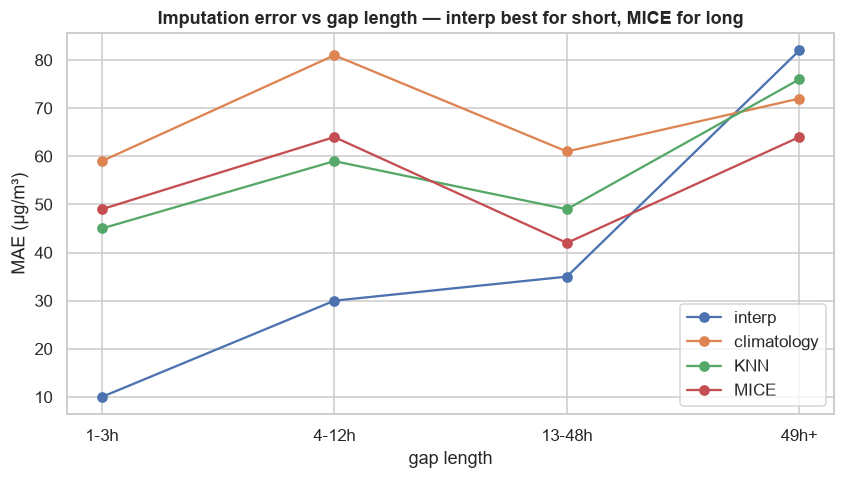

In [4]:
bins = pd.cut(glen[mask], [0, 3, 12, 48, 10000], labels=["1-3h", "4-12h", "13-48h", "49h+"])
strat = pd.DataFrame({name: pd.Series(np.abs(p.values[mask]-t)).groupby(bins, observed=True).mean()
                      for name, p in preds.items()}).round(0)
print("MAE by gap length:"); print(strat.to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
for name in ["interp", "climatology", "KNN", "MICE"]:
    ax.plot(strat.index, strat[name], "o-", label=name)
ax.set_xlabel("gap length"); ax.set_ylabel("MAE (µg/m³)"); ax.set_title("Imputation error vs gap length — interp best for short, MICE for long")
ax.legend(); eda.savefig(fig, "p3_by_gaplength.png"); plt.show()

### 5. Seeing it — one long gap, every method

Overlay the methods on a single long artificial gap. Interpolation draws a **flat, lifeless line**
straight through the daily cycle; climatology and MICE **trace the rhythm**; ffill makes a step.

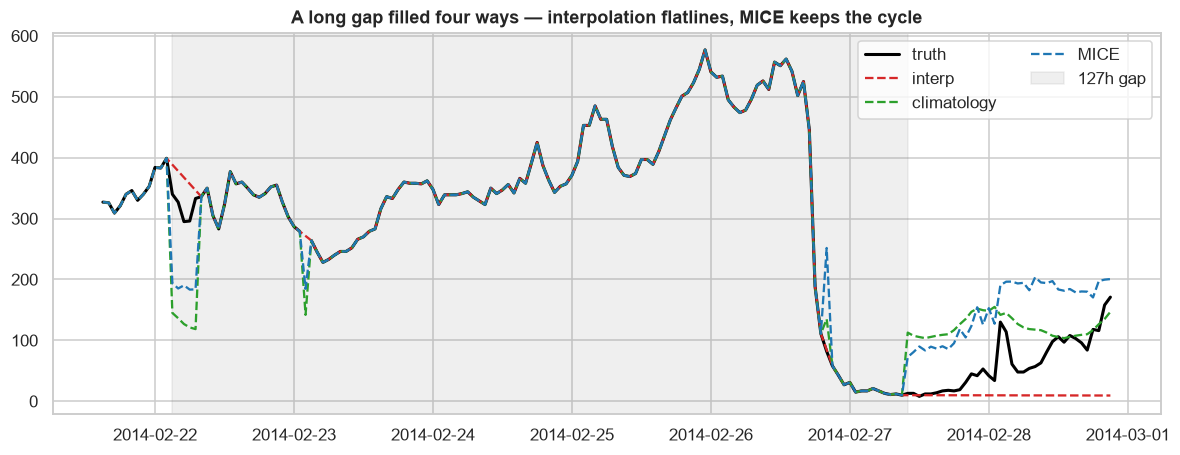

In [5]:
# find the longest masked gap in the window and show a window around it
gl = pd.Series(glen, index=win.index); longest_end = gl.idxmax(); L = int(gl.max())
seg = slice(win.index.get_loc(longest_end) - L - 12, win.index.get_loc(longest_end) + 36)
idx = win.index[seg]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(idx, truth.values[seg], color="black", lw=2, label="truth")
for name, c in [("interp", "tab:red"), ("climatology", "tab:green"), ("MICE", "tab:blue")]:
    ax.plot(idx, preds[name].values[seg], "--", color=c, label=name)
ax.axvspan(idx[12], idx[12+L], color="grey", alpha=0.12, label=f"{L}h gap")
ax.set_title("A long gap filled four ways — interpolation flatlines, MICE keeps the cycle"); ax.legend(ncol=2)
eda.savefig(fig, "p3_longgap.png"); plt.show()

### 6. Distribution preservation — a hidden trap

Accuracy isn't everything: a method can be "close on average" yet **destroy the variability** of the
data, which would bias any downstream variance / extreme-event analysis. Compare the spread of the
imputed values to the truth — **climatology collapses it** (everything becomes a smooth average),
while KNN/MICE keep realistic variation.

In [6]:
print("std of imputed values vs the true std (%.0f µg/m³) at the masked points:" % t.std())
sd = pd.Series({name: p.values[mask].std() for name, p in preds.items()}).round(0).sort_values()
print(sd.to_string())
print("\n-> climatology & interp UNDERSTATE variability; KNN/MICE preserve it. 'Accurate' != 'faithful'.")

std of imputed values vs the true std (96 µg/m³) at the masked points:
climatology    20.0
interp         54.0
ffill          60.0
MICE           74.0
KNN            76.0

-> climatology & interp UNDERSTATE variability; KNN/MICE preserve it. 'Accurate' != 'faithful'.


### 7. The recommendation — a hybrid

No method dominates, so combine their strengths: **interpolate short gaps (≤48 h), MICE the long
ones**. This beats every single method on both MAE and RMSE — *and* preserves variability.

In [7]:
hyb = imp.hybrid(gappy, WEATHER, short_max=48)
e = np.abs(hyb.values[mask] - t)
print("HYBRID (interp ≤48h + MICE >48h):  MAE %.1f  RMSE %.1f  std %.0f" % (e.mean(), np.sqrt((e**2).mean()), hyb.values[mask].std()))
print("best single method was interp MAE %.1f / MICE RMSE %.1f -> the hybrid wins both." % (board.MAE.min(), board.RMSE.min()))

HYBRID (interp ≤48h + MICE >48h):  MAE 45.1  RMSE 72.1  std 72
best single method was interp MAE 54.2 / MICE RMSE 80.6 -> the hybrid wins both.


### 8. Build the final clean series

Apply the hybrid to the **real** gaps and persist a gap-free `pm25` for the modelling parts to
come. We keep a `pm25_was_imputed` flag so later work can treat filled values with appropriate
caution (especially the long-outage stretches).

In [8]:
full = df.copy()
full["pm25_was_imputed"] = full["pm25"].isna()
full["pm25"] = imp.hybrid(df["pm25"], df[["TEMP", "DEWP", "PRES", "Iws"]], short_max=48)
print("remaining missing pm25:", int(full.pm25.isna().sum()), "| imputed:", int(full.pm25_was_imputed.sum()))
full.to_csv(data.DATA_PROC / "beijing_imputed.csv") if hasattr(data, "DATA_PROC") else full.to_csv("data/processed/beijing_imputed.csv")
print("wrote data/processed/beijing_imputed.csv (gap-free, with an imputation flag)")

remaining missing pm25: 0 | imputed: 2067


wrote data/processed/beijing_imputed.csv (gap-free, with an imputation flag)


### Takeaways

- **Evaluate imputation by masking** values that mimic the real gaps — don't just pick a method by
  reputation. The proper score is reconstruction error on the masked points.
- **Gap length is everything.** Interpolation is near-perfect for **short** gaps (PM2.5's 0.97 hour-
  to-hour persistence) but **fails on long** ones; multivariate **MICE/KNN** win there by leaning on
  weather + the seasonal cycle.
- **Accuracy ≠ faithfulness.** Climatology can look passable on MAE yet **collapse the variance**
  (std 20 vs 96) — a trap for any later variability/extreme analysis.
- **The hybrid** (interpolate ≤48 h, MICE beyond) beats every single method *and* preserves the
  distribution — and we keep an **imputation flag** so long-outage fills are never mistaken for data.

**Next:** Part 4 — multi-seasonal time-series foundations on the now-complete series, then pollution
forecasting using the persistence and meteorology the EDA uncovered.